# L04 - Cloning Quasars 
Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey. \
Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform. \
Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures) \
Think about the cosmology of quasars. How do you think they are distributed? \
Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation?

In [3]:
import numpy as np
import random
import time
import math
import matplotlib.pyplot as plt

In [55]:
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()
# select the first 10000 points
data = data[:100000]
z = data['redshift']

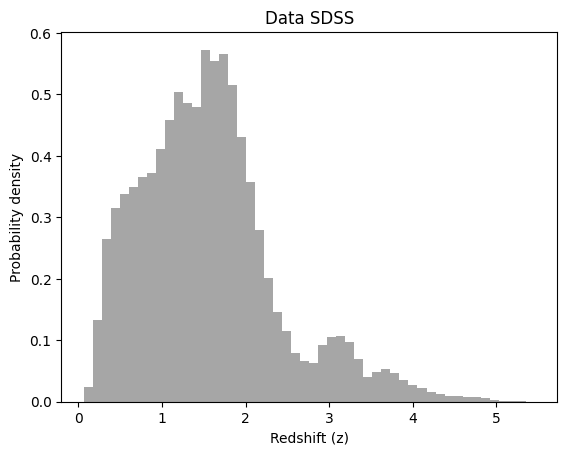

In [57]:
plt.hist(z, bins = 50, alpha=0.7, color='grey', density=True)
plt.xlabel("Redshift (z)")
plt.ylabel("Probability density")
plt.title("Data SDSS")
plt.show()

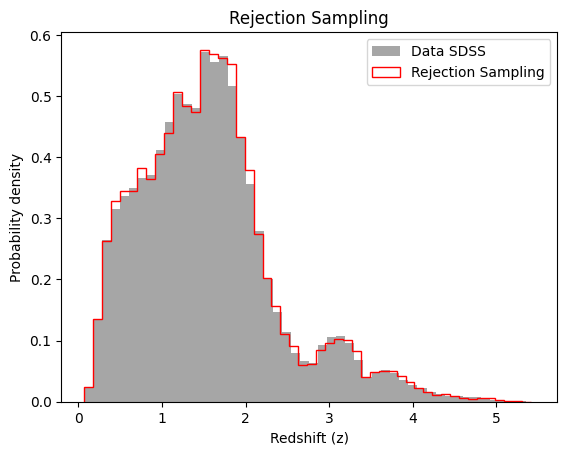

In [59]:
# Method 1 : Rejection Sampling

N = 100000

h, edges = np.histogram(z, bins = 50, density=True)
z_min, z_max = z.min(), z.max()
y_max = max(h)

x = np.random.uniform(z.min(), z.max(), N)

indices = np.digitize(x, edges) -1    # bin of every generated point 
h_values = h[indices]                 # bin high
y = np.random.uniform(0, y_max, N)    # uniform distribution

good_values = x[y < h_values]

plt.hist(z, bins = 50, alpha=0.7, color='grey', density=True,  label="Data SDSS")
plt.hist(good_values, bins = 50, alpha=1, color='red', density=True, histtype='step', label="Rejection Sampling")
plt.xlabel("Redshift (z)")
plt.ylabel("Probability density")
plt.title("Rejection Sampling")
plt.legend()
plt.show()

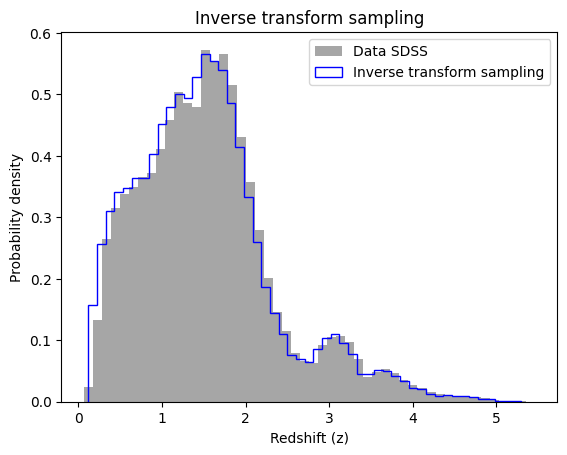

In [61]:
# Method 2: inverse transform sampling

bin_centers = (edges[:-1] + edges[1:]) / 2

cdf = np.cumsum(h)/np.sum(h) # The CDF is the integral (cumulative sum) of the PDF (given by the histogram)

u = np.random.uniform(0, 1, 100000)
z_inverse = np.interp(u, cdf, bin_centers)

plt.hist(z, bins=50, alpha=0.7, color='grey', density=True,  label="Data SDSS")
plt.hist(z_inverse, bins=50, alpha=1, color='blue', density=True, histtype='step', label="Inverse transform sampling")
plt.xlabel("Redshift (z)")
plt.ylabel("Probability density")
plt.legend()
plt.title("Inverse transform sampling")
plt.show()

In [63]:
import astropy
from astropy.cosmology import Planck18
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

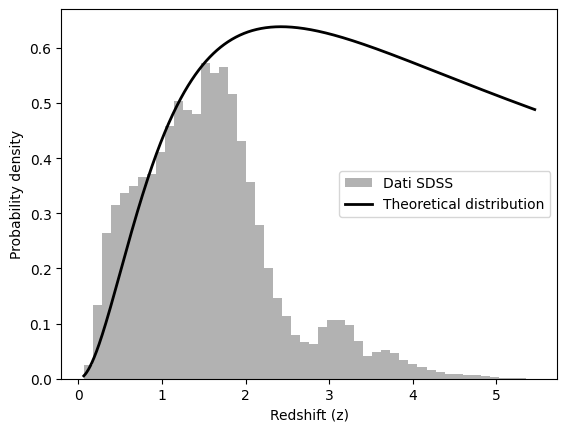

In [71]:
def theoretical_distribution(z):
    return Planck18.differential_comoving_volume(z).value

z_th = np.linspace(z_min, z_max, 1000)
pdf = [theoretical_distribution(i)/6.6e10 for i in z_th] #normalization may "by eye"

plt.hist(z, bins=50, density=True, alpha=0.6, color='gray', label="Dati SDSS")
plt.plot(z_th, pdf, 'k-', label="Theoretical distribution", linewidth=2)
plt.xlabel("Redshift (z)")
plt.ylabel("Probability density")
plt.legend()
plt.show()